In [192]:
# Pytorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# For data preprocess
import numpy as np
import pandas as pd
import csv
import os

# For figure plotting
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

In [193]:
# Set random seed
seed = 42069
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

In [194]:
# Utilities
def get_device():
    if torch.cuda.is_available():
        return "cuda"
    else:
        return "cpu"
    
def plot_learning_curve(loss_record, title=""):
    total_steps = len(loss_record["train"])
    x_1 = range(total_steps)
    x_2 = x_1[::len(loss_record["train"]) // len(loss_record["validation"])]
    figure(figsize=(6, 4))
    plt.plot(x_1, loss_record["train"], c="tab:red", label="train")
    plt.plot(x_2, loss_record["validation"], c="tab:cyan", label="validation")
    plt.ylim(0.0, 5.0)
    plt.xlabel("Training Steps")
    plt.ylabel("Loss")
    plt.title(f"Learning curve of {title}.")
    plt.legend()
    plt.show()
    
def plot_prediction(validation_set, model, device, lim=35, preds=None, targets=None):
    if preds is None or targets is None:
        model.eval()
        preds, targets = [], []
        for x, y in validation_set:
            x, y = x.to(device), y.to(device)
            with torch.no_grad():
                pred = model(x)
                preds.append(pred.detach().cpu())
                targets.append(y.detach().cpu())
        preds = torch.cat(preds, dim=0).numpy()
        targets = torch.cat(targets, dim=0).numpy()
        
    figure(figsize=(5, 5))
    plt.scatter(targets, preds, c='r', alpha=0.5)
    plt.plot([-0.2, lim], [-0.2, lim], c='b')
    plt.xlim(-0.2, lim)
    plt.ylim(-0.2, lim)
    plt.xlabel("Ground Truth")
    plt.ylabel("Prediction")
    plt.title("Ground Truth v.s. Prediction")
    plt.show()

In [195]:
# Data file path
training_data_path = "./data/covid.train.csv"
test_data_path = "./data/covid.test.csv"

In [196]:
# Data preprocess: read data
training_data = pd.read_csv(training_data_path, index_col=0)
print(f"number of samples: {training_data.shape[0]}")
print(f"number of features: {training_data.shape[1]}") # One-hot encoding for 40 states and features an targets for three days
print(training_data.head(10)) # List 10 rows of training data

number of samples: 2700
number of features: 94
     AL   AK   AZ   AR   CA   CO   CT   FL   GA   ID  ...  restaurant.2  \
id                                                    ...                 
0   1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...     23.812411   
1   1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...     23.682974   
2   1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...     23.593983   
3   1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...     22.576992   
4   1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...     22.091433   
5   1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...     21.679396   
6   1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...     21.970599   
7   1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...     22.682459   
8   1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...     23.156434   
9   1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...     23.661191   

    spent_time.2  large_event.2  public_transit.2  a

In [197]:
# Data preprocess: feature selection
# Because this homework is a regression task, so we can use the Pearson correlation coefficient to find useful features which have a strong linear correlation with target
tmp = training_data.iloc[:, 40:]
tmp = tmp.rename(columns={
    tmp.columns[53]: "target"
})
corr_matrix = tmp.corr(method="pearson", numeric_only=True)
feature_corr = corr_matrix["target"].drop("target")
feature_corr_sorted = feature_corr.abs().sort_values(ascending=False).reset_index()
feature_corr_sorted.columns = ["feature", "corr_abs"]
feature_corr_sorted["col_index"] = feature_corr_sorted["feature"].map(tmp.columns.get_loc)
print(feature_corr_sorted)

                   feature  corr_abs  col_index
0        tested_positive.1  0.991012         35
1          tested_positive  0.981165         17
2             hh_cmnty_cli  0.879724          2
3           hh_cmnty_cli.1  0.879438         20
4           hh_cmnty_cli.2  0.878218         38
5           nohh_cmnty_cli  0.869938          3
6         nohh_cmnty_cli.1  0.869278         21
7         nohh_cmnty_cli.2  0.867535         39
8                      cli  0.838504          0
9                    cli.1  0.838224         18
10                   cli.2  0.835751         36
11                     ili  0.830527          1
12                   ili.1  0.829200         19
13                   ili.2  0.826075         37
14      worried_finances.2  0.485843         52
15      worried_finances.1  0.480958         34
16        worried_finances  0.475462         16
17        public_transit.2  0.450436         47
18        public_transit.1  0.449079         29
19          public_transit  0.448360    

In [198]:
# Get features with strong linear correlation with target (corr_abs > 0.5)
selected_indices = feature_corr_sorted[
    feature_corr_sorted["corr_abs"].abs() > 0.5
]["col_index"].tolist()
# Add 40 because there are one-hot encoding for 40 states ahead
for i in range(len(selected_indices)):
    selected_indices[i] += 40
for j in range (40):
    selected_indices.append(j)
selected_indices.sort()
print(selected_indices)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 57, 58, 59, 60, 61, 75, 76, 77, 78, 79]


In [199]:
# Define dataset class
class COVID19Dataset(Dataset):
    def __init__(self, path, selected_indices, mode="train"):
        self.mode = mode
        with open(path, 'r') as f:
            data = list(csv.reader(f))
            data = np.array(data[1:])[:, 1:].astype(float)
            
        feature_indices = list(range(93))
        if len(selected_indices) > 0:
            feature_indices = selected_indices
            
        if mode == "test":
            data = data[:, feature_indices]
            self.data = torch.FloatTensor(data)
        else:
            target = data[:, -1]
            data = data[:, feature_indices]
            # split data into training set and validation set
            if mode == "train":
                data_indices = [i for i in range(len(data)) if i % 10 != 0]
            elif mode == "validation":
                data_indices = [i for i in range(len(data)) if i % 10 == 0]
            self.data = torch.FloatTensor(data[data_indices])
            self.target = torch.FloatTensor(target[data_indices])
        
        # Standardization: adjust the scale of numeric features, accelerate optimization
        self.data[:, 40:] = (self.data[:, 40:] - self.data[:, 40:].mean(dim=0, keepdim=True)) / self.data[:, 40:].std(dim=0, keepdim=True)
        
        self.dim = self.data.shape[1]
        
        print(f"Finished read the {mode} set of the COVID19 dataset, {len(self.data)} samples found, each dim = {self.dim}")
        
    def __getitem__(self, idx):
        '''
        Get a sample by a given index
        '''
        if self.mode in ["train", "validation"]:
            return self.data[idx], self.target[idx]
        else:
            return self.data[idx]
        
    def __len__(self):
        '''
        Get number of samples of the dataset
        '''
        return len(self.data)

In [200]:
# Define the dataloader
def get_dataloader(path, mode, batch_size, selected_indices, n_jobs=0):
    dataset = COVID19Dataset(path, mode=mode, selected_indices=selected_indices)
    dataloader = DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=(mode == "train"),
        drop_last=False,
        num_workers=n_jobs,
        pin_memory=True
    )
    return dataloader

In [201]:
# Define the DNN model
class DNN(nn.Module):
    def __init__(self, input_dim, lambda_l2):
        super(DNN, self).__init__()
        
        # Because this is a simple regression task, and the number of samples is small, so we prefer a simple model
        self.net = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
        
        self.lambda_l2 = lambda_l2
        self.criterion = nn.MSELoss(reduction="mean")
        
    def forward(self, x):
        '''
        Execute a forward propagation
        '''
        return self.net(x).squeeze(1)
    
    def cal_loss(self, pred, target):
        '''
        Calculate a loss with L2 regulation
        '''
        origin_loss = self.criterion(pred, target)
        decay = 0
        for p in self.net.parameters():
            decay += p.pow(2).sum()
            
        loss = origin_loss + self.lambda_l2 * decay
        return loss

In [202]:
# Define the validation process
def validate(validation_set, model, device):
    model.eval() # Set evaluation mode
    total_loss = 0
    for x, y in validation_set:
        x, y = x.to(device), y.to(device)
        with torch.no_grad():
            pred = model(x)
            loss = model.cal_loss(pred, y)
        total_loss += loss.detach().cpu().item() * len(x)
    mean_loss = total_loss / len(validation_set.dataset)
    return mean_loss

# Define the train process
def train(training_set, validation_set, model, config, device):
    max_epochs = config["max_epochs"] # Maximum number of epochs
    
    # Setup optimizer
    optimizer = getattr(torch.optim, config["optimizer"])(model.parameters(), **config["optim_hyparams"])
    
    min_loss = 1000
    loss_record = {"train": [], "validation": []}
    early_stop_count = 0 # Eearly count: if the model has converged, stop training
    epoch = 0
    
    while epoch < max_epochs:
        epoch += 1
        model.train() # Set train mode
        for x, y in training_set:
            optimizer.zero_grad()
            x, y = x.to(device), y.to(device)
            pred = model(x)
            loss = model.cal_loss(pred, y)
            loss.backward() # Compute gradient
            optimizer.step() # Update weights
            loss_record["train"].append(loss.detach().cpu().item())
            
        # At each epoch evaluate the model after training
        validation_loss = validate(validation_set, model, device)
        if validation_loss < min_loss:
            # The model has been improved, save it
            min_loss = validation_loss
            print(f"Saving model, epoch = {epoch:4d}, loss = {min_loss:.4f}")
            torch.save(model.state_dict(), config["save_path"])
            early_stop_count = 0
        else:
            early_stop_count += 1
        
        loss_record["validation"].append(validation_loss)
        
        if early_stop_count > config["early_stop"]:
            break
        
    print(f"Finished training after {epoch} epochs")
    return min_loss, loss_record

In [203]:
# Define the test process
def test(test_set, model, device):
    model.eval() # Set evaluation mode
    preds = []
    for x in test_set:
        x = x.to(device)
        with torch.no_grad():
            pred = model(x)
            preds.append(pred.detach().cpu())
    preds = torch.cat(preds, dim=0).numpy()
    return preds

In [204]:
device = get_device()
os.makedirs("models", exist_ok=True)

config = {
    "max_epochs": 3000,
    "batch_size": 64,
    "optimizer": "SGD",
    "optim_hyparams": {
        "lr": 0.001,
        "momentum": 0.9
    },
    "lambda_l2": 1e-4,
    "early_stop": 200,
    "save_path": "models/model.pth"
}

In [205]:
# Load data
training_set = get_dataloader(path=training_data_path, mode="train", batch_size=config["batch_size"], selected_indices=selected_indices)
validation_set = get_dataloader(path=training_data_path, mode="validation", batch_size=config["batch_size"], selected_indices=selected_indices)
test_set = get_dataloader(path=test_data_path, mode="test", batch_size=config["batch_size"], selected_indices=selected_indices)

Finished read the train set of the COVID19 dataset, 2430 samples found, each dim = 54
Finished read the validation set of the COVID19 dataset, 270 samples found, each dim = 54
Finished read the test set of the COVID19 dataset, 893 samples found, each dim = 54


In [206]:
# Load model
model = DNN(training_set.dataset.dim, config["lambda_l2"]).to(device)

In [207]:
# Train
model_loss, model_loss_record = train(training_set, validation_set, model, config, device)

Saving model, epoch =    1, loss = 10.8662
Saving model, epoch =    2, loss = 1.5384
Saving model, epoch =    3, loss = 1.1593
Saving model, epoch =    5, loss = 1.1141
Saving model, epoch =    6, loss = 1.0523
Saving model, epoch =    7, loss = 1.0255
Saving model, epoch =    9, loss = 1.0081
Saving model, epoch =   10, loss = 0.9973
Saving model, epoch =   11, loss = 0.9797
Saving model, epoch =   13, loss = 0.9567
Saving model, epoch =   14, loss = 0.9315
Saving model, epoch =   15, loss = 0.9245
Saving model, epoch =   19, loss = 0.9066
Saving model, epoch =   21, loss = 0.8943
Saving model, epoch =   23, loss = 0.8809
Saving model, epoch =   26, loss = 0.8652
Saving model, epoch =   31, loss = 0.8571
Saving model, epoch =   34, loss = 0.8504
Saving model, epoch =   42, loss = 0.8385
Saving model, epoch =   49, loss = 0.8374
Saving model, epoch =   51, loss = 0.8371
Saving model, epoch =   54, loss = 0.8361
Saving model, epoch =   60, loss = 0.8263
Saving model, epoch =   67, loss 

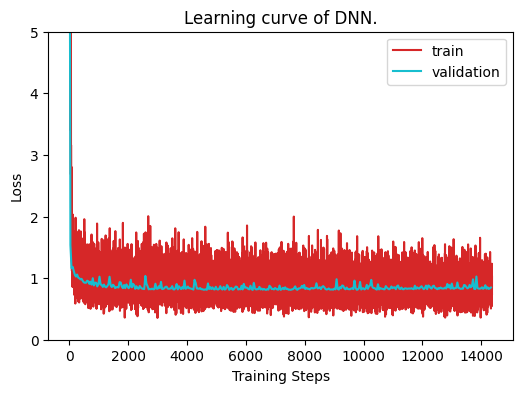

In [208]:
# Plot the learning curve
plot_learning_curve(model_loss_record, title="DNN")

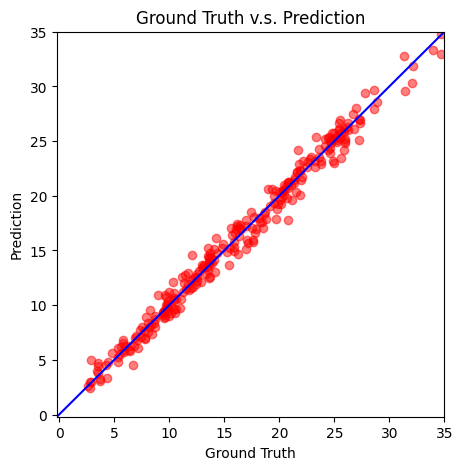

In [209]:
del model
model = DNN(training_set.dataset.dim, config["lambda_l2"]).to(device)
check_point = torch.load(config["save_path"], map_location="cpu")
model.load_state_dict(check_point)
plot_prediction(validation_set, model, device)

In [210]:
# Prediction
def save_prediction(preds, file):
    with open(file, 'w') as f:
        writer = csv.writer(f)
        writer.writerow(["id", "tested_positive"])
        for id, pred in enumerate(preds):
            writer.writerow([id, pred])
    print(f"Saved results to {file}")
    
preds = test(test_set, model, device)
save_prediction(preds, "pred.csv")

Saved results to pred.csv
